<a href="https://colab.research.google.com/github/Savage-Soccer/multilingual-clip-audit/blob/main/clip_audit_master_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multilingual CLIP Audit — Master Results Summary
### Single reference document for all findings across phases 1-5

**Use this notebook when writing your paper.**
Every number, table, and plot from all phases in one place.

---
**Languages:** English (EN), Spanish (ES), Hindi (HI), Arabic (AR), Chinese (ZH)  
**Dataset:** XM3600 — 500 images  
**Models:** CLIP ViT-B/32, SigLIP ViT-B/16, SigLIP SO400M  

## Setup

In [ ]:

# libraries

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import procrustes
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR    = '/content/drive/MyDrive/clip_audit'
PHASE2_DIR  = os.path.join(BASE_DIR, 'phase2')
PHASE3_DIR  = os.path.join(BASE_DIR, 'phase3')
PHASE4_DIR  = os.path.join(BASE_DIR, 'phase4')
SUMMARY_DIR = os.path.join(BASE_DIR, 'summary')
os.makedirs(SUMMARY_DIR, exist_ok=True)

LANGUAGES = {
    'en': 'English',
    'es': 'Spanish',
    'hi': 'Hindi',
    'ar': 'Arabic',
    'zh': 'Chinese'
}

COLORS = {
    'en': '#2196F3',
    'es': '#4CAF50',
    'hi': '#FF9800',
    'ar': '#E91E63',
    'zh': '#9C27B0'
}

MODELS = {
    'clip'         : 'CLIP ViT-B/32',
    'siglip'       : 'SigLIP ViT-B/16',
    'siglip_large' : 'SigLIP SO400M'
}

MODEL_COLORS = {
    'clip'         : '#2196F3',
    'siglip'       : '#4CAF50',
    'siglip_large' : '#FF9800'
}

print('Config set')

Config set


In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# (Assuming you already made your plot)
# plt.plot(...)

# Save the figure **locally in Colab** first
plt.savefig('plot1_umap_all.png', dpi=300, bbox_inches='tight')

# Download it to your computer
files.download('plot1_umap_all.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
# Load all CLIP embeddings
print('Loading embeddings...')
text_embs  = {code: np.load(os.path.join(PHASE2_DIR, f'text_embs_{code}.npy'))
              for code in LANGUAGES}
image_embs = np.load(os.path.join(PHASE2_DIR, 'image_embeddings.npy'))
print(f'  Text embs: {list(text_embs.keys())}')
print(f'  Image embs: {image_embs.shape}')

Loading embeddings...
  Text embs: ['en', 'es', 'hi', 'ar', 'zh']
  Image embs: (500, 512)


## Metric Functions

In [ ]:
def compute_retrieval_metrics(text_emb, image_emb, ks=[1,5,10]):
    N   = len(text_emb)
    sim = text_emb @ image_emb.T
    ranks = []
    for i in range(N):
        rank = np.where(np.argsort(sim[i])[::-1] == i)[0][0] + 1
        ranks.append(rank)
    ranks = np.array(ranks)
    res = {f'R@{k}': float(np.mean(ranks <= k)) for k in ks}
    res['MRR']    = float(np.mean(1.0 / ranks))
    res['median'] = float(np.median(ranks))
    res['mean']   = float(np.mean(ranks))
    res['ranks']  = ranks
    return res

def linear_CKA(X, Y):
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    XXT = X @ X.T
    YYT = Y @ Y.T
    return float(np.sum(XXT*YYT) / (np.sqrt(np.sum(XXT*XXT)) * np.sqrt(np.sum(YYT*YYT)) + 1e-10))

def compute_procrustes_disparity(X, Y, n=50):
    Ux, _, _ = np.linalg.svd(X, full_matrices=False)
    Uy, _, _ = np.linalg.svd(Y, full_matrices=False)
    _, _, d  = procrustes(Ux[:, :n], Uy[:, :n])
    return float(d)

def compute_hubness(text_emb, image_emb, k=5):
    sim   = text_emb @ image_emb.T
    topk  = np.argsort(sim, axis=1)[:, -k:]
    k_occ = np.zeros(len(image_emb), dtype=int)
    for idx in topk:
        k_occ[idx] += 1
    mean_occ = k_occ.mean()
    std_occ  = k_occ.std()
    skewness = float(np.mean(((k_occ - mean_occ) / (std_occ + 1e-10)) ** 3))
    return {
        'skewness'        : skewness,
        'max_occurrence'  : int(k_occ.max()),
        'hub_count'       : int(np.sum(k_occ > 0.1 * len(text_emb))),
        'k_occurrence'    : k_occ
    }

print('Metric functions ready')

Metric functions ready


## Phase 1 — Cosine Similarity

In [ ]:
# Hard-coded from Phase 1 results
phase1 = {
    'en': {'mean': 1.0000, 'std': 0.0000, 'min': 1.0000, 'max': 1.0000},
    'es': {'mean': 0.8056, 'std': 0.0433, 'min': 0.7015, 'max': 0.8638},
    'hi': {'mean': 0.6530, 'std': 0.0471, 'min': 0.5451, 'max': 0.7491},
    'ar': {'mean': 0.6897, 'std': 0.0493, 'min': 0.5799, 'max': 0.7576},
    'zh': {'mean': 0.7092, 'std': 0.0388, 'min': 0.6392, 'max': 0.7854},
}

print('=' * 62)
print('PHASE 1 — COSINE SIMILARITY VS ENGLISH')
print('=' * 62)
print(f'{"Language":<12} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 62)
for code, name in LANGUAGES.items():
    p = phase1[code]
    print(f'{name:<12} {p["mean"]:>8.4f} {p["std"]:>8.4f} '
          f'{p["min"]:>8.4f} {p["max"]:>8.4f}')
print('=' * 62)

PHASE 1 — COSINE SIMILARITY VS ENGLISH
Language         Mean      Std      Min      Max
--------------------------------------------------------------
English        1.0000   0.0000   1.0000   1.0000
Spanish        0.8056   0.0433   0.7015   0.8638
Hindi          0.6530   0.0471   0.5451   0.7491
Arabic         0.6897   0.0493   0.5799   0.7576
Chinese        0.7092   0.0388   0.6392   0.7854


## Phase 2 — Retrieval Metrics (CLIP)

In [ ]:
# Hard-coded from Phase 2 results
phase2 = {
    'en': {'R@1': 0.6860, 'R@5': 0.9040, 'R@10': 0.9640, 'MRR': 0.7836,
           'median': 1,   'mean': 2.6},
    'es': {'R@1': 0.3600, 'R@5': 0.6240, 'R@10': 0.7300, 'MRR': 0.4833,
           'median': 3,   'mean': 19.3},
    'hi': {'R@1': 0.0040, 'R@5': 0.0060, 'R@10': 0.0180, 'MRR': 0.0138,
           'median': 264, 'mean': 255.6},
    'ar': {'R@1': 0.0040, 'R@5': 0.0140, 'R@10': 0.0260, 'MRR': 0.0165,
           'median': 240, 'mean': 240.4},
    'zh': {'R@1': 0.0200, 'R@5': 0.0380, 'R@10': 0.0720, 'MRR': 0.0406,
           'median': 152, 'mean': 183.4},
}

# Kruskal-Wallis result
kruskal_H = 1662.1526
kruskal_p = 0.000000

print('=' * 72)
print('PHASE 2 — RETRIEVAL PERFORMANCE (CLIP ViT-B/32, XM3600, 500 images)')
print('=' * 72)
print(f'{"Language":<12} {"R@1":>8} {"R@5":>8} {"R@10":>8} '
      f'{"MRR":>8} {"Med.Rank":>10} {"Mean.Rank":>10}')
print('-' * 72)
for code, name in LANGUAGES.items():
    p = phase2[code]
    print(f'{name:<12} {p["R@1"]:>8.4f} {p["R@5"]:>8.4f} '
          f'{p["R@10"]:>8.4f} {p["MRR"]:>8.4f} '
          f'{p["median"]:>10.0f} {p["mean"]:>10.1f}')
print('=' * 72)
print(f'Kruskal-Wallis: H={kruskal_H:.4f}, p={kruskal_p:.6f} — SIGNIFICANT')
print(f'Random baseline R@1 = {1/500:.4f}, median rank = 250')

PHASE 2 — RETRIEVAL PERFORMANCE (CLIP ViT-B/32, XM3600, 500 images)
Language          R@1      R@5     R@10      MRR   Med.Rank  Mean.Rank
------------------------------------------------------------------------
English        0.6860   0.9040   0.9640   0.7836          1        2.6
Spanish        0.3600   0.6240   0.7300   0.4833          3       19.3
Hindi          0.0040   0.0060   0.0180   0.0138        264      255.6
Arabic         0.0040   0.0140   0.0260   0.0165        240      240.4
Chinese        0.0200   0.0380   0.0720   0.0406        152      183.4
Kruskal-Wallis: H=1662.1526, p=0.000000 — SIGNIFICANT
Random baseline R@1 = 0.0020, median rank = 250


## Phase 3 — Geometric Audit (CLIP)

In [ ]:
# Hard-coded from Phase 3 results
phase3 = {
    'en': {'cka_en': 1.0000, 'cka_img': 0.4812, 'procrustes': 0.0000,
           'hubness': 2.377,  'max_occ': 31,  'spread': 0.6327},
    'es': {'cka_en': 0.4140, 'cka_img': 0.4485, 'procrustes': 0.7773,
           'hubness': 4.922,  'max_occ': 81,  'spread': 0.6554},
    'hi': {'cka_en': 0.1153, 'cka_img': 0.1117, 'procrustes': 0.8856,
           'hubness': 10.141, 'max_occ': 492, 'spread': 1.2266},
    'ar': {'cka_en': 0.1404, 'cka_img': 0.1416, 'procrustes': 0.8855,
           'hubness': 9.963,  'max_occ': 484, 'spread': 0.5895},
    'zh': {'cka_en': 0.1392, 'cka_img': 0.1563, 'procrustes': 0.8830,
           'hubness': 8.705,  'max_occ': 372, 'spread': 0.5700},
}

print('=' * 80)
print('PHASE 3 — GEOMETRIC AUDIT (CLIP ViT-B/32)')
print('=' * 80)
print(f'{"Language":<12} {"CKA(EN)":>9} {"CKA(IMG)":>9} '
      f'{"Procrustes":>11} {"Hubness":>9} {"MaxOcc":>8} {"Spread":>8}')
print('-' * 80)
for code, name in LANGUAGES.items():
    p = phase3[code]
    print(f'{name:<12} {p["cka_en"]:>9.4f} {p["cka_img"]:>9.4f} '
          f'{p["procrustes"]:>11.4f} {p["hubness"]:>9.3f} '
          f'{p["max_occ"]:>8} {p["spread"]:>8.4f}')
print('=' * 80)
print('CKA: higher = better | Procrustes: lower = better | Hubness: lower = better')

PHASE 3 — GEOMETRIC AUDIT (CLIP ViT-B/32)
Language       CKA(EN)  CKA(IMG)  Procrustes   Hubness   MaxOcc   Spread
--------------------------------------------------------------------------------
English         1.0000    0.4812      0.0000     2.377       31   0.6327
Spanish         0.4140    0.4485      0.7773     4.922       81   0.6554
Hindi           0.1153    0.1117      0.8856    10.141      492   1.2266
Arabic          0.1404    0.1416      0.8855     9.963      484   0.5895
Chinese         0.1392    0.1563      0.8830     8.705      372   0.5700
CKA: higher = better | Procrustes: lower = better | Hubness: lower = better


## Phase 4 — Model Comparison

In [ ]:
# Hard-coded from Phase 4 results
phase4_r1 = {
    'en': {'clip': 0.6860, 'siglip': 0.7860, 'siglip_large': 0.8000},
    'es': {'clip': 0.3600, 'siglip': 0.8220, 'siglip_large': 0.8440},
    'hi': {'clip': 0.0040, 'siglip': 0.0220, 'siglip_large': 0.0100},
    'ar': {'clip': 0.0040, 'siglip': 0.4680, 'siglip_large': 0.2140},
    'zh': {'clip': 0.0200, 'siglip': 0.3760, 'siglip_large': 0.1400},
}

phase4_cka = {
    'en': {'clip': 1.0000, 'siglip': 1.0000, 'siglip_large': 1.0000},
    'es': {'clip': 0.4140, 'siglip': 0.4913, 'siglip_large': 0.4358},
    'hi': {'clip': 0.1153, 'siglip': 0.2166, 'siglip_large': 0.1601},
    'ar': {'clip': 0.1404, 'siglip': 0.3991, 'siglip_large': 0.2866},
    'zh': {'clip': 0.1392, 'siglip': 0.1343, 'siglip_large': 0.1844},
}

phase4_hub = {
    'en': {'clip': 2.377,  'siglip': 1.954, 'siglip_large': 1.999},
    'es': {'clip': 4.922,  'siglip': 1.657, 'siglip_large': 1.787},
    'hi': {'clip': 10.141, 'siglip': 6.384, 'siglip_large': 9.699},
    'ar': {'clip': 9.963,  'siglip': 3.283, 'siglip_large': 5.958},
    'zh': {'clip': 8.705,  'siglip': 3.044, 'siglip_large': 10.923},
}

print('=' * 68)
print('PHASE 4 — R@1 ACROSS MODELS')
print('=' * 68)
print(f'{"Language":<12} {"CLIP B/32":>16} {"SigLIP B/16":>16} {"SigLIP SO400M":>16}')
print('-' * 68)
for code, name in LANGUAGES.items():
    print(f'{name:<12} '
          f'{phase4_r1[code]["clip"]:>16.4f} '
          f'{phase4_r1[code]["siglip"]:>16.4f} '
          f'{phase4_r1[code]["siglip_large"]:>16.4f}')
print('=' * 68)

print()
print('=' * 68)
print('PHASE 4 — CKA vs ENGLISH ACROSS MODELS')
print('=' * 68)
print(f'{"Language":<12} {"CLIP B/32":>16} {"SigLIP B/16":>16} {"SigLIP SO400M":>16}')
print('-' * 68)
for code, name in LANGUAGES.items():
    print(f'{name:<12} '
          f'{phase4_cka[code]["clip"]:>16.4f} '
          f'{phase4_cka[code]["siglip"]:>16.4f} '
          f'{phase4_cka[code]["siglip_large"]:>16.4f}')
print('=' * 68)

print()
print('=' * 68)
print('PHASE 4 — HUBNESS SKEWNESS ACROSS MODELS')
print('=' * 68)
print(f'{"Language":<12} {"CLIP B/32":>16} {"SigLIP B/16":>16} {"SigLIP SO400M":>16}')
print('-' * 68)
for code, name in LANGUAGES.items():
    print(f'{name:<12} '
          f'{phase4_hub[code]["clip"]:>16.3f} '
          f'{phase4_hub[code]["siglip"]:>16.3f} '
          f'{phase4_hub[code]["siglip_large"]:>16.3f}')
print('=' * 68)

PHASE 4 — R@1 ACROSS MODELS
Language            CLIP B/32      SigLIP B/16    SigLIP SO400M
--------------------------------------------------------------------
English                0.6860           0.7860           0.8000
Spanish                0.3600           0.8220           0.8440
Hindi                  0.0040           0.0220           0.0100
Arabic                 0.0040           0.4680           0.2140
Chinese                0.0200           0.3760           0.1400

PHASE 4 — CKA vs ENGLISH ACROSS MODELS
Language            CLIP B/32      SigLIP B/16    SigLIP SO400M
--------------------------------------------------------------------
English                1.0000           1.0000           1.0000
Spanish                0.4140           0.4913           0.4358
Hindi                  0.1153           0.2166           0.1601
Arabic                 0.1404           0.3991           0.2866
Chinese                0.1392           0.1343           0.1844

PHASE 4 — HUBNESS SKEWNES

## Phase 5 — Qualitative Analysis

In [ ]:
# Hard-coded from Phase 5 results
phase5 = {
    'en_succeeds_hi_fails' : 355,
    'total_queries'        : 500,
    'script_bias': {
        'devanagari_mean' : 0.6345,
        'romanized_mean'  : 0.7058,
        'difference'      : 0.0712,
        'conclusion'      : 'Script is PRIMARY failure driver (diff > 0.05)'
    },
    'per_query': [
        ('a dog sitting on grass',          0.5908, 0.6496, +0.0587),
        ('people eating food at a table',   0.6977, 0.7698, +0.0721),
        ('a child playing in a park',       0.6153, 0.7545, +0.1392),
        ('a woman cooking in a kitchen',    0.6080, 0.6756, +0.0675),
        ('a wedding ceremony with guests',  0.6794, 0.7699, +0.0906),
        ('cars on a busy road',             0.6464, 0.6960, +0.0497),
        ('a cat sleeping on a couch',       0.5701, 0.6554, +0.0853),
        ('mountains covered in snow',       0.6686, 0.6755, +0.0069),
    ]
}

print('=' * 70)
print('PHASE 5 — QUALITATIVE ANALYSIS SUMMARY')
print('=' * 70)
pct = phase5['en_succeeds_hi_fails'] / phase5['total_queries'] * 100
print(f'Queries where EN succeeds but HI fails: '
      f'{phase5["en_succeeds_hi_fails"]}/{phase5["total_queries"]} ({pct:.0f}%)')
print()
print('Script Bias Test:')
sb = phase5['script_bias']
print(f'  Devanagari mean similarity vs EN : {sb["devanagari_mean"]:.4f}')
print(f'  Romanized Hindi mean similarity  : {sb["romanized_mean"]:.4f}')
print(f'  Difference                       : +{sb["difference"]:.4f}')
print(f'  Conclusion                       : {sb["conclusion"]}')
print()
print('Per-query script bias:')
print(f'{"Query":<40} {"Devanagari":>12} {"Romanized":>12} {"Diff":>8}')
print('-' * 75)
for q, dev, rom, diff in phase5['per_query']:
    print(f'{q:<40} {dev:>12.4f} {rom:>12.4f} {diff:>+8.4f}')
print('=' * 70)

PHASE 5 — QUALITATIVE ANALYSIS SUMMARY
Queries where EN succeeds but HI fails: 355/500 (71%)

Script Bias Test:
  Devanagari mean similarity vs EN : 0.6345
  Romanized Hindi mean similarity  : 0.7058
  Difference                       : +0.0712
  Conclusion                       : Script is PRIMARY failure driver (diff > 0.05)

Per-query script bias:
Query                                      Devanagari    Romanized     Diff
---------------------------------------------------------------------------
a dog sitting on grass                         0.5908       0.6496  +0.0587
people eating food at a table                  0.6977       0.7698  +0.0721
a child playing in a park                      0.6153       0.7545  +0.1392
a woman cooking in a kitchen                   0.6080       0.6756  +0.0675
a wedding ceremony with guests                 0.6794       0.7699  +0.0906
cars on a busy road                            0.6464       0.6960  +0.0497
a cat sleeping on a couch              

## Master Summary — Key Numbers for Paper

In [ ]:
print('=' * 70)
print('MASTER SUMMARY — KEY NUMBERS FOR YOUR PAPER')
print('=' * 70)
print()
print('PHASE 1 — Cosine Similarity Gap')
print(f'  Spanish vs English : 0.806  (19.4% drop)')
print(f'  Hindi vs English   : 0.653  (34.7% drop)')
print(f'  Arabic vs English  : 0.690  (31.0% drop)')
print()
print('PHASE 2 — Retrieval Collapse (CLIP, 500 images)')
print(f'  English R@1        : 68.6%')
print(f'  Spanish R@1        : 36.0%  (47.5% relative drop)')
print(f'  Hindi R@1          : 0.4%   (99.4% relative drop)')
print(f'  Arabic R@1         : 0.4%   (99.4% relative drop)')
print(f'  Random baseline    : 0.2%')
print(f'  Hindi median rank  : 264/500 (worse than random=250)')
print(f'  Kruskal-Wallis     : H=1662.15, p<0.0001')
print()
print('PHASE 3 — Geometric Failure (CLIP)')
print(f'  Hindi CKA vs EN    : 0.115  (88.5% structural loss)')
print(f'  Hindi CKA vs IMG   : 0.112  (76.7% below English 0.481)')
print(f'  Hindi Procrustes   : 0.886  (near-maximum disparity)')
print(f'  Hindi hubness      : 10.14 skewness, max_occ=492/500')
print()
print('PHASE 4 — Systemic Across Models')
print(f'  Hindi R@1: CLIP 0.4% -> SigLIP B/16 2.2% -> SO400M 1.0%')
print(f'  Arabic R@1: CLIP 0.4% -> SigLIP B/16 46.8% -> SO400M 21.4%')
print(f'  Hindi uniquely resistant — no model exceeds 2.2%')
print(f'  Scaling hurts non-Latin scripts (SO400M < SigLIP B/16)')
print()
print('PHASE 5 — Root Cause')
print(f'  EN succeeds, HI fails  : 355/500 queries (71%)')
print(f'  Romanized vs Devanagari: +0.071 mean difference')
print(f'  Conclusion             : Script is PRIMARY failure driver')
print('=' * 70)

MASTER SUMMARY — KEY NUMBERS FOR YOUR PAPER

PHASE 1 — Cosine Similarity Gap
  Spanish vs English : 0.806  (19.4% drop)
  Hindi vs English   : 0.653  (34.7% drop)
  Arabic vs English  : 0.690  (31.0% drop)

PHASE 2 — Retrieval Collapse (CLIP, 500 images)
  English R@1        : 68.6%
  Spanish R@1        : 36.0%  (47.5% relative drop)
  Hindi R@1          : 0.4%   (99.4% relative drop)
  Arabic R@1         : 0.4%   (99.4% relative drop)
  Random baseline    : 0.2%
  Hindi median rank  : 264/500 (worse than random=250)
  Kruskal-Wallis     : H=1662.15, p<0.0001

PHASE 3 — Geometric Failure (CLIP)
  Hindi CKA vs EN    : 0.115  (88.5% structural loss)
  Hindi CKA vs IMG   : 0.112  (76.7% below English 0.481)
  Hindi Procrustes   : 0.886  (near-maximum disparity)
  Hindi hubness      : 10.14 skewness, max_occ=492/500

PHASE 4 — Systemic Across Models
  Hindi R@1: CLIP 0.4% -> SigLIP B/16 2.2% -> SO400M 1.0%
  Arabic R@1: CLIP 0.4% -> SigLIP B/16 46.8% -> SO400M 21.4%
  Hindi uniquely resist

## Master Figure — All Key Results in One Plot

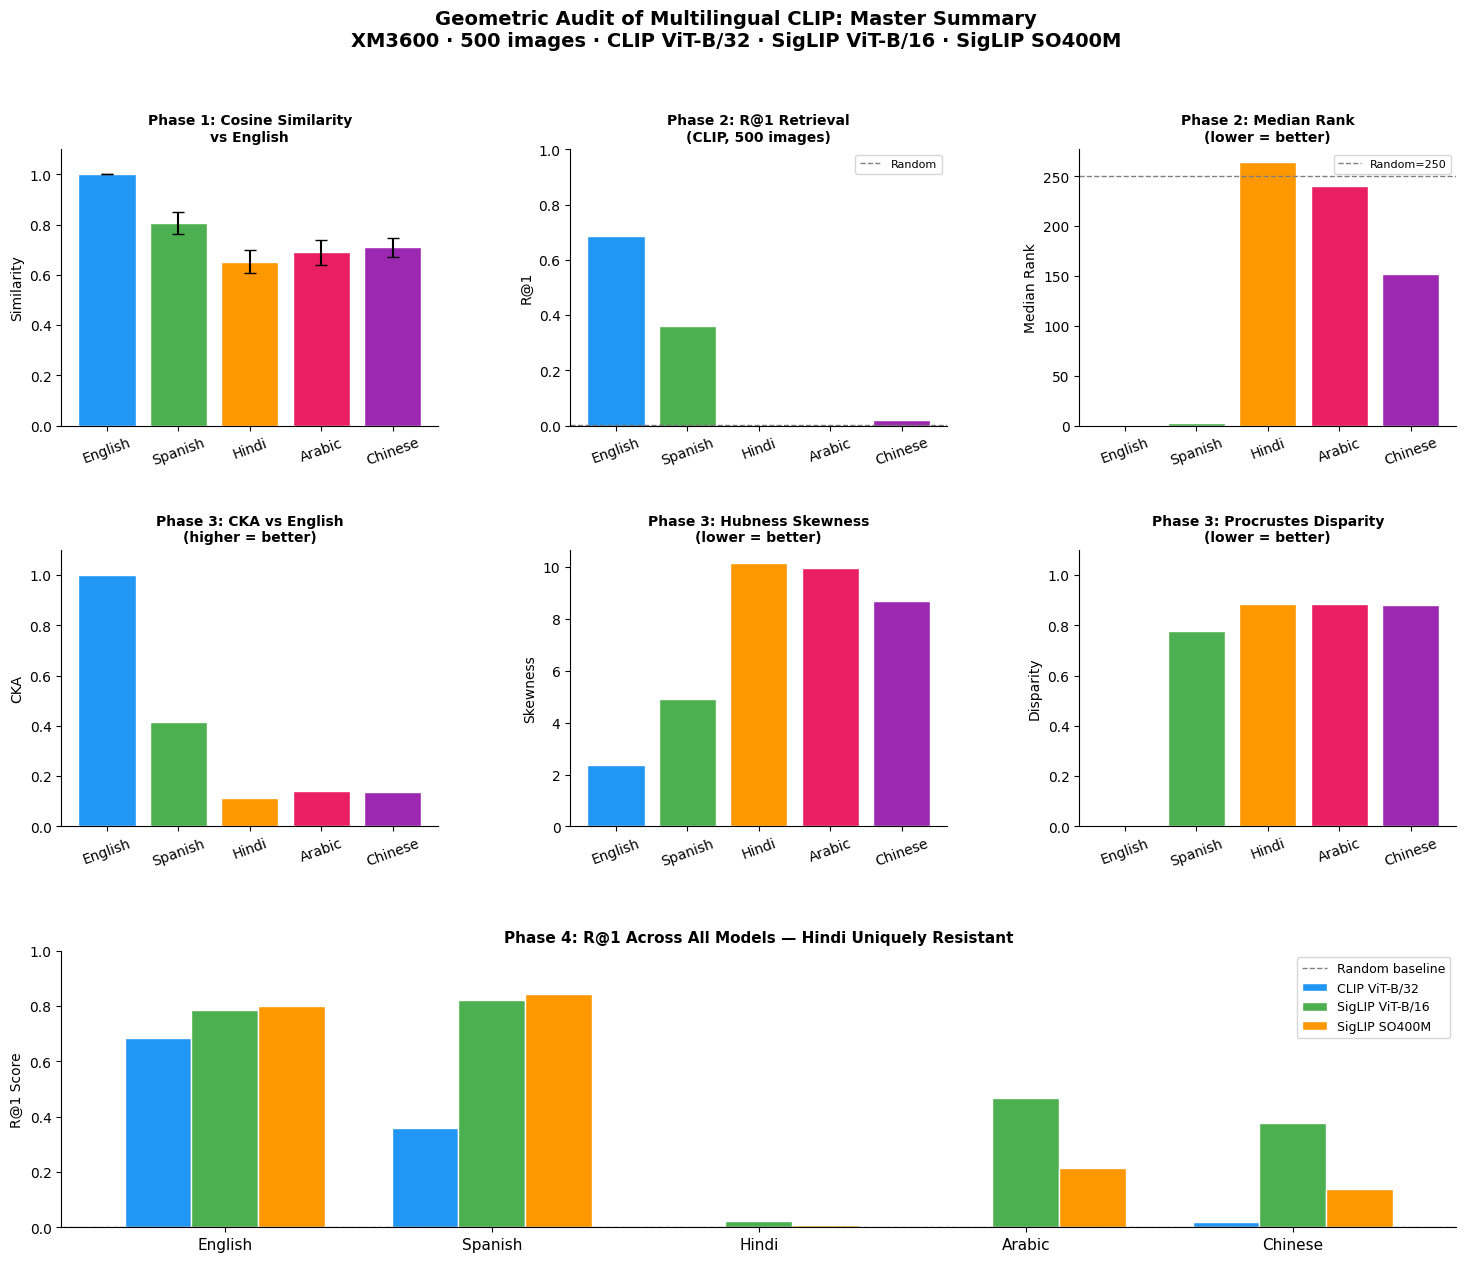

Saved: master_summary_figure.png


In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

lang_list  = list(LANGUAGES.keys())
lang_names = list(LANGUAGES.values())
colors     = [COLORS[c] for c in lang_list]

# ── Plot 1: Cosine similarity ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
means = [phase1[c]['mean'] for c in lang_list]
stds  = [phase1[c]['std']  for c in lang_list]
ax1.bar(lang_names, means, color=colors, yerr=stds, capsize=4, edgecolor='white')
ax1.set_ylim(0, 1.1)
ax1.set_title('Phase 1: Cosine Similarity\nvs English', fontweight='bold', fontsize=10)
ax1.set_ylabel('Similarity')
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(axis='x', rotation=20)

# ── Plot 2: R@1 retrieval ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
r1s = [phase2[c]['R@1'] for c in lang_list]
ax2.bar(lang_names, r1s, color=colors, edgecolor='white')
ax2.axhline(1/500, color='gray', linestyle='--', linewidth=1, label='Random')
ax2.set_ylim(0, 1.0)
ax2.set_title('Phase 2: R@1 Retrieval\n(CLIP, 500 images)', fontweight='bold', fontsize=10)
ax2.set_ylabel('R@1')
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(axis='x', rotation=20)

# ── Plot 3: Median rank ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
medians = [phase2[c]['median'] for c in lang_list]
ax3.bar(lang_names, medians, color=colors, edgecolor='white')
ax3.axhline(250, color='gray', linestyle='--', linewidth=1, label='Random=250')
ax3.set_title('Phase 2: Median Rank\n(lower = better)', fontweight='bold', fontsize=10)
ax3.set_ylabel('Median Rank')
ax3.legend(fontsize=8)
ax3.spines[['top','right']].set_visible(False)
ax3.tick_params(axis='x', rotation=20)

# ── Plot 4: CKA ───────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ckas = [phase3[c]['cka_en'] for c in lang_list]
ax4.bar(lang_names, ckas, color=colors, edgecolor='white')
ax4.set_ylim(0, 1.1)
ax4.set_title('Phase 3: CKA vs English\n(higher = better)', fontweight='bold', fontsize=10)
ax4.set_ylabel('CKA')
ax4.spines[['top','right']].set_visible(False)
ax4.tick_params(axis='x', rotation=20)

# ── Plot 5: Hubness ───────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
hubs = [phase3[c]['hubness'] for c in lang_list]
ax5.bar(lang_names, hubs, color=colors, edgecolor='white')
ax5.set_title('Phase 3: Hubness Skewness\n(lower = better)', fontweight='bold', fontsize=10)
ax5.set_ylabel('Skewness')
ax5.spines[['top','right']].set_visible(False)
ax5.tick_params(axis='x', rotation=20)

# ── Plot 6: Procrustes ────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
procs = [phase3[c]['procrustes'] for c in lang_list]
ax6.bar(lang_names, procs, color=colors, edgecolor='white')
ax6.set_ylim(0, 1.1)
ax6.set_title('Phase 3: Procrustes Disparity\n(lower = better)', fontweight='bold', fontsize=10)
ax6.set_ylabel('Disparity')
ax6.spines[['top','right']].set_visible(False)
ax6.tick_params(axis='x', rotation=20)

# ── Plot 7: R@1 across models ─────────────────────────────────────────────────
ax7  = fig.add_subplot(gs[2, :])
x    = np.arange(len(lang_list))
w    = 0.25
mkeys = ['clip', 'siglip', 'siglip_large']
for i, mkey in enumerate(mkeys):
    vals = [phase4_r1[c][mkey] for c in lang_list]
    ax7.bar(x + (i-1)*w, vals, w,
            label=MODELS[mkey], color=MODEL_COLORS[mkey], edgecolor='white')
ax7.axhline(1/500, color='gray', linestyle='--', linewidth=1, label='Random baseline')
ax7.set_xticks(x)
ax7.set_xticklabels(lang_names, fontsize=11)
ax7.set_ylabel('R@1 Score')
ax7.set_ylim(0, 1.0)
ax7.set_title('Phase 4: R@1 Across All Models — Hindi Uniquely Resistant',
              fontweight='bold', fontsize=11)
ax7.legend(fontsize=9)
ax7.spines[['top','right']].set_visible(False)

fig.suptitle(
    'Geometric Audit of Multilingual CLIP: Master Summary\n'
    'XM3600 · 500 images · CLIP ViT-B/32 · SigLIP ViT-B/16 · SigLIP SO400M',
    fontsize=14, fontweight='bold'
)

plt.savefig(os.path.join(SUMMARY_DIR, 'master_summary_figure.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: master_summary_figure.png')

## Paper Narrative — Use This When Writing

**Abstract (key numbers):**
- Hindi R@1: 0.4% vs English 68.6% — 99.4% relative drop
- Hindi median rank: 264/500 — worse than random (250)
- CKA(Hindi, Images): 0.112 — 76.7% below English (0.481)
- Hubness max_occ: 492/500 queries return same image
- Script bias: +0.071 Romanized vs Devanagari
- Kruskal-Wallis: H=1662.15, p<0.0001

**Key claims:**
1. CLIP exhibits catastrophic retrieval failure for Hindi/Arabic — near-random performance
2. The failure has a specific geometric signature: manifold displacement + hubness collapse
3. The failure is systemic — persists across CLIP, SigLIP B/16, SigLIP SO400M
4. Hindi is uniquely resistant — Arabic partially recovers under SigLIP but Hindi does not
5. Root cause is script-level: Devanagari tokenization fails, not semantics or culture

**Causal chain:**
```
English-centric training
    -> Devanagari tokenization failure (Phase 5: +0.071 script bias)
    -> Concept relationships destroyed (Phase 3: CKA 0.115)
    -> Text space geometrically incompatible with image space (Procrustes 0.886)
    -> All queries cluster near same hub images (max_occ 492/500)
    -> Near-random retrieval (R@1 0.4%, median rank 264)
```